### **Student Name:** Amey Khodke

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

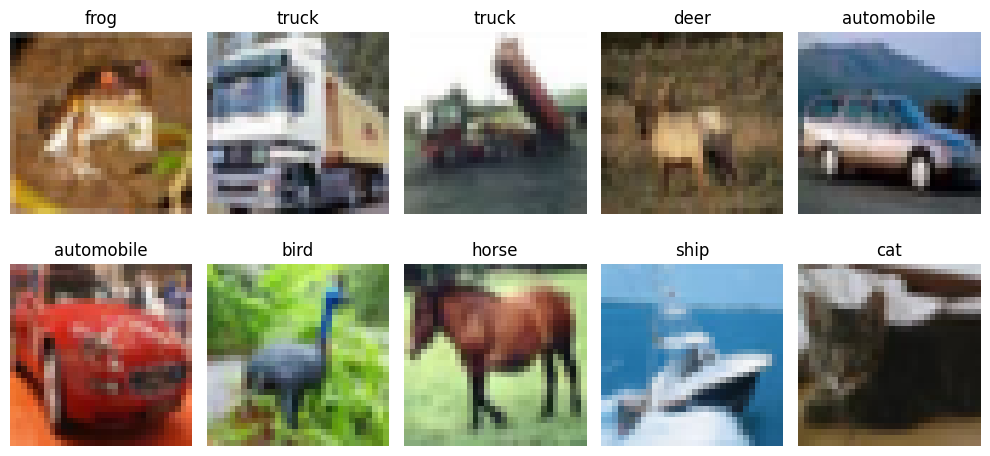

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.2683 - loss: 1.9925 - val_accuracy: 0.3310 - val_loss: 1.8528
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3199 - loss: 1.8637 - val_accuracy: 0.3470 - val_loss: 1.8062
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3380 - loss: 1.8165 - val_accuracy: 0.3738 - val_loss: 1.7476
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3509 - loss: 1.7774 - val_accuracy: 0.3914 - val_loss: 1.7226
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3623 - loss: 1.7509 - val_accuracy: 0.4048 - val_loss: 1.6954
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3745 - loss: 1.7276 - val_accuracy: 0.4132 - val_loss: 1.6614
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3752 - loss: 1.7142 - val_accuracy: 0.3916 - val_loss: 1.6996
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.3802 - loss: 1.7165 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4351 - loss: 1.6208
ANN Test Accuracy: 0.4350999891757965


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 119ms/step - accuracy: 0.4647 - loss: 1.5027 - val_accuracy: 0.4046 - val_loss: 1.7815
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.6091 - loss: 1.1195 - val_accuracy: 0.5806 - val_loss: 1.1869
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 129ms/step - accuracy: 0.6729 - loss: 0.9429 - val_accuracy: 0.6496 - val_loss: 1.0225
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 134s 118ms/step - accuracy: 0.7134 - loss: 0.8304 - val_accuracy: 0.6772 - val_loss: 0.9565
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 118ms/step - accuracy: 0.7444 - loss: 0.7314 - val_accuracy: 0.6304 - val_loss: 1.0650
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.7690 - loss: 0.6591 - val_accuracy: 0.6412 - val_loss: 1.1439
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.7945 - loss: 0.5872 - val_accuracy: 0.6814 - val_loss: 1.0062
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.8126 - los

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7197 - loss: 0.9408
CNN Test Accuracy: 0.7196999788284302


## 📈 Compare Learning Curves

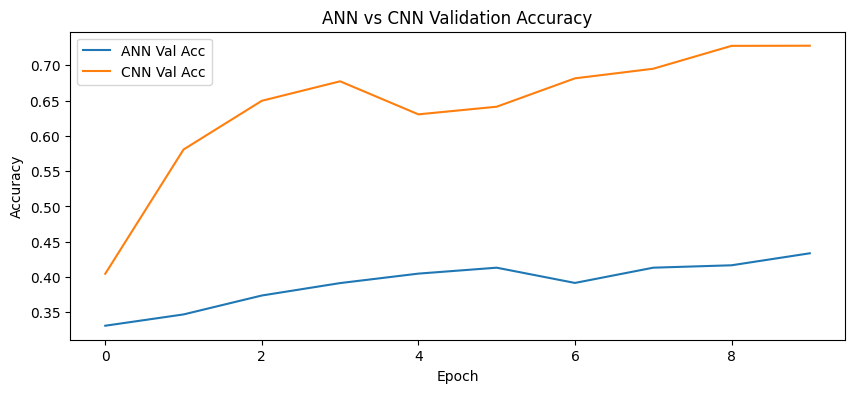

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.3842 - loss: 1.6874 - val_accuracy: 0.5068 - val_loss: 1.3686
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.4857 - loss: 1.4419 - val_accuracy: 0.5716 - val_loss: 1.1984
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 52ms/step - accuracy: 0.5218 - loss: 1.3461 - val_accuracy: 0.5908 - val_loss: 1.1506
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 52ms/step - accuracy: 0.5446 - loss: 1.2841 - val_accuracy: 0.5990 - val_loss: 1.1187
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.5623 - loss: 1.2436 - val_accuracy: 0.6050 - val_loss: 1.1138
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 52ms/step - accuracy: 0.5724 - loss: 1.2114 - val_accuracy: 0.6290 - val_loss: 1.0528
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.5787 - loss: 1.1952 - val_accuracy: 0.6300 - val_loss: 1.0434
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5871 -

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4351
1,CNN,0.7197


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

1. Increase ANN layers and observe performance

In [12]:
ann = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3. Increase epochs to 20

ANN MODEL

In [13]:
history_ann = ann.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.2539 - loss: 2.0167 - val_accuracy: 0.3276 - val_loss: 1.8651
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.3105 - loss: 1.8861 - val_accuracy: 0.3216 - val_loss: 1.8521
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 61ms/step - accuracy: 0.3358 - loss: 1.8302 - val_accuracy: 0.3520 - val_loss: 1.8107
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 63ms/step - accuracy: 0.3521 - loss: 1.7897 - val_accuracy: 0.3832 - val_loss: 1.7198
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3552 - loss: 1.7713 - val_accuracy: 0.3864 - val_loss: 1.7218
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 63ms/step - accuracy: 0.3685 - loss: 1.7473 - val_accuracy: 0.4056 - val_loss: 1.7072
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3729 - loss: 1.7260 - val_accuracy: 0.4076 - val_loss: 1.6815
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.3760 - loss: 1.7195 - 

In [16]:
ann_test_loss, ann_test_acc = ann.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4417 - loss: 1.5710
ANN Test Accuracy: 0.4417000114917755


CNN MODEL 

In [14]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.8604 - loss: 0.3850 - val_accuracy: 0.6872 - val_loss: 1.0547
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.8702 - loss: 0.3624 - val_accuracy: 0.7154 - val_loss: 1.1477
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 122ms/step - accuracy: 0.8796 - loss: 0.3365 - val_accuracy: 0.7438 - val_loss: 0.9600
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.8906 - loss: 0.3002 - val_accuracy: 0.7292 - val_loss: 1.0248
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.8932 - loss: 0.2981 - val_accuracy: 0.7144 - val_loss: 1.1959
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.9002 - loss: 0.2782 - val_accuracy: 0.7270 - val_loss: 1.1546
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.9084 - loss: 0.2540 - val_accuracy: 0.7286 - val_loss: 1.1580
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 119ms/step - accuracy: 0.9135 - loss:

In [25]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7231 - loss: 1.2660
CNN Test Accuracy: 0.7231000065803528


4. Added Early Stopping

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.8929 - loss: 0.3220 - val_accuracy: 0.7334 - val_loss: 1.2502
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 66ms/step - accuracy: 0.9180 - loss: 0.2414 - val_accuracy: 0.7364 - val_loss: 1.2903
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9172 - loss: 0.2406 - val_accuracy: 0.6898 - val_loss: 1.4516
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 141s 65ms/step - accuracy: 0.9239 - loss: 0.2240 - val_accuracy: 0.7326 - val_loss: 1.3183


5. Add **data augmentation training**

In [15]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.6180 - loss: 1.0880 - val_accuracy: 0.6678 - val_loss: 0.9374
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 96ms/step - accuracy: 0.6201 - loss: 1.0782 - val_accuracy: 0.6534 - val_loss: 0.9898
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.6261 - loss: 1.0708 - val_accuracy: 0.6516 - val_loss: 1.0178
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 96ms/step - accuracy: 0.6258 - loss: 1.0608 - val_accuracy: 0.6542 - val_loss: 0.9965
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.6278 - loss: 1.0574 - val_accuracy: 0.6536 - val_loss: 1.0130
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.6337 - loss: 1.0482 - val_accuracy: 0.6560 - val_loss: 0.9962
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.6340 - loss: 1.0448 - val_accuracy: 0.6926 - val_loss: 0.8774
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.6370 - loss: 1.0366 - 

In [20]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6952 - loss: 0.8821
Augmented CNN Accuracy: 0.6952000260353088


In [21]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "CNN + Data Augmentation"
    ],
    "Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_acc
    ]
})

comparison

,Model,Accuracy
0,ANN,0.4417
1,CNN,0.7271
2,CNN + Data Augmentation,0.6952


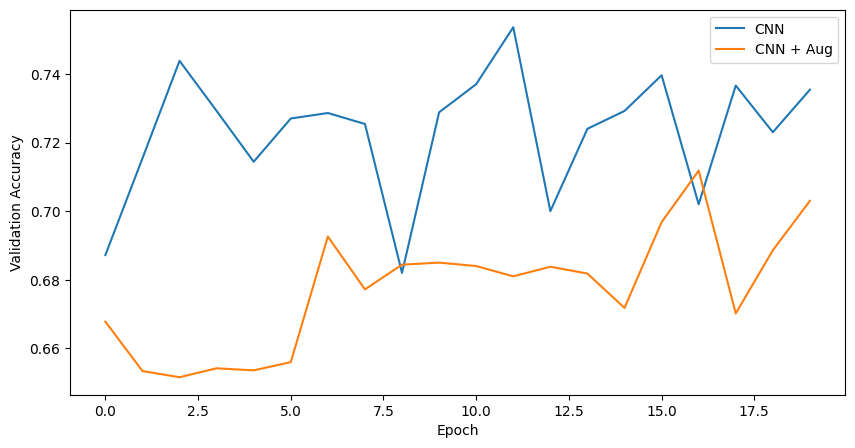

In [22]:
plt.figure(figsize=(10,5))
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(aug_history.history['val_accuracy'],label='CNN + Aug')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**